# Liver Disease Detection using Machine Learning

# Model Evaluation

## Objective

Evaluate and compare multiple machine learning models using different performance metrics and select the best model for deployment.

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [22]:
logistic_model = joblib.load("../models/logistic_model.pkl")

In [23]:
import joblib

logistic_model = joblib.load("../models/logistic_model.pkl")
decision_tree = joblib.load("../models/decision_tree.pkl")
random_forest = joblib.load("../models/random_forest.pkl")
svm_model = joblib.load("../models/svm_model.pkl")
xgb_model = joblib.load("../models/xgb_model.pkl")

print("All models loaded successfully!")

All models loaded successfully!


In [24]:
import numpy as np

X_test = np.load("../models/X_test.npy")
y_test = np.load("../models/y_test.npy")

print("Test data loaded successfully!")
print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

Test data loaded successfully!
X_test Shape : (114, 10)
y_test Shape : (114,)


In [25]:
logistic_pred = logistic_model.predict(X_test)

In [26]:
decision_pred = decision_tree.predict(X_test)

In [27]:
rf_pred = random_forest.predict(X_test)

In [28]:
svm_pred = svm_model.predict(X_test)

In [29]:
xgb_pred = xgb_model.predict(X_test)

In [30]:
accuracy = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, decision_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

accuracy

,Model,Accuracy
0,Logistic Regression,0.710526
1,Decision Tree,0.578947
2,Random Forest,0.745614
3,SVM,0.728070
4,XGBoost,0.710526


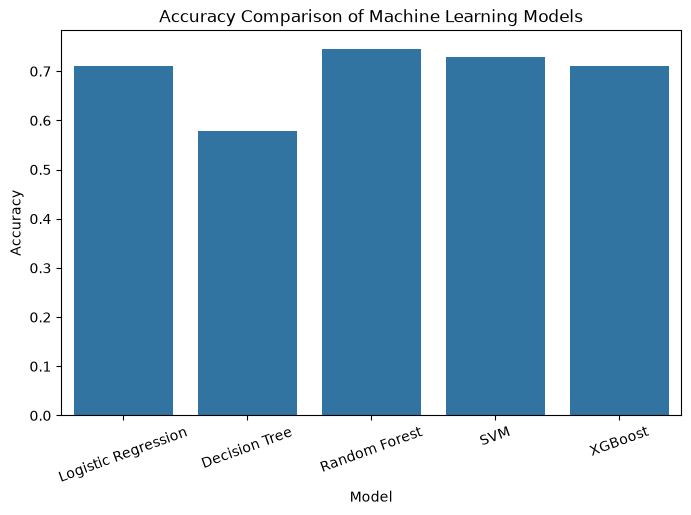

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=accuracy
)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xticks(rotation=20)

plt.show()

In [32]:
best_model = accuracy.loc[accuracy["Accuracy"].idxmax()]

print("Best Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"] * 100, 2), "%")

Best Model : Random Forest
Accuracy : 74.56 %


In [33]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81        85
           1       0.41      0.31      0.35        29

    accuracy                           0.71       114
   macro avg       0.60      0.58      0.58       114
weighted avg       0.69      0.71      0.70       114



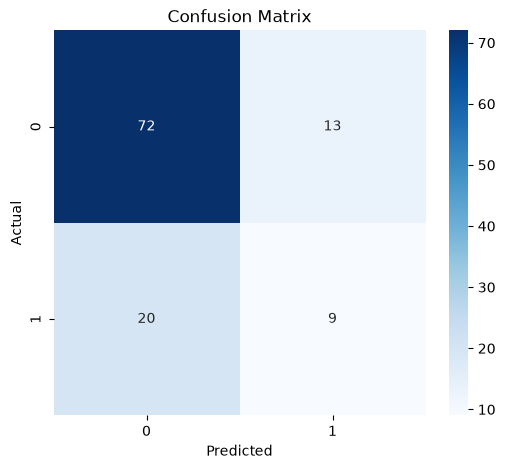

In [34]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
joblib.dump(xgb_model, "../models/liver_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [36]:
joblib.dump(random_forest, "../models/liver_model.pkl")

['../models/liver_model.pkl']